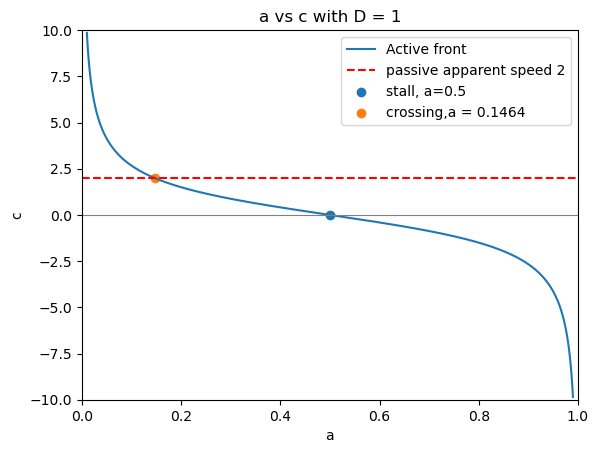

In [17]:
import numpy as np
import matplotlib.pyplot as plt

D = 1.0
a = np.linspace(0.01, 0.99, 1000)

c = np.sqrt(D) * (1 - 2*a) / np.sqrt(a * (1 - a))
c_apparent = 2 * np.sqrt(D)
crossing = (2 - np.sqrt(2)) / 4

fig, ax = plt.subplots()

ax.plot(a, c, label="Active front")
ax.axhline(c_apparent, color="red", linestyle="--", label=r"passive apparent speed 2")
ax.axhline(0, color="gray", linewidth=0.8)



ax.scatter([0.5], [0], label="stall, a=0.5")
ax.scatter([crossing], [c_apparent], label="crossing,a = 0.1464")

ax.set(
    xlabel="a",
    ylabel="c",
    title="a vs c with D = 1",
    xlim=(0, 1),
    ylim=(-10, 10)
)
ax.legend()
plt.show()


In [4]:
import numpy as np
from scipy.optimize import brentq

V0 = 16.13  
EN = 0.0   
Mg = 1.0   

def B(V):
    return 1 / (1 + (Mg / 3.57) * np.exp(-V / V0))

def f(V):
    return 1 + (V - EN) * (1 - B(V)) / V0

Vr= brentq(f, -90, 0)

print(Vr,"mV")


-26.956804012627437 mV


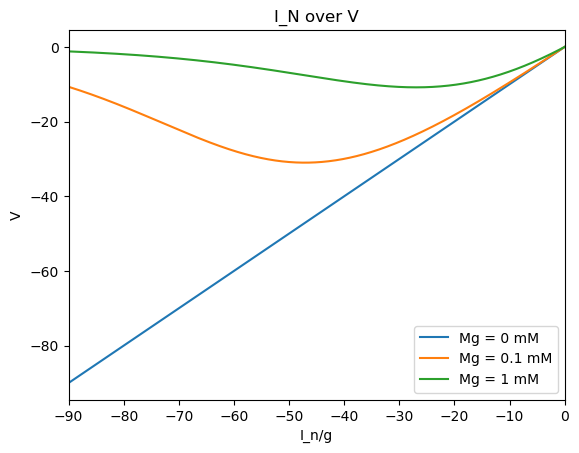

In [12]:
import numpy as np
import matplotlib.pyplot as plt

V0 = 16.13 
EN = 0.0    

def B(V, Mg):
    return 1 / (1 + (Mg / 3.57) * np.exp(-V / V0))


V = np.linspace(-90, 0, 1000)

fig, ax = plt.subplots()

for Mg in [0.0, 0.1, 1.0]:
    current = B(V, Mg) * (V - EN)
    ax.plot(V, current, label=f"Mg = {Mg:g} mM")


ax.set(
    xlabel="I_n/g",
    ylabel=r"V",
    title=r"I_N over V",
    xlim=(-90, 0)
)
ax.legend()
plt.show()

vtau = 2
mean = 9.996 
variance = 25.01
skewness = 0.6699

vtau = 20
mean = 10.01 
variance = 2.487
skewness = 0.2095

vtau = 200
mean = 10 
variance = 0.2496
skewness = 0.06669



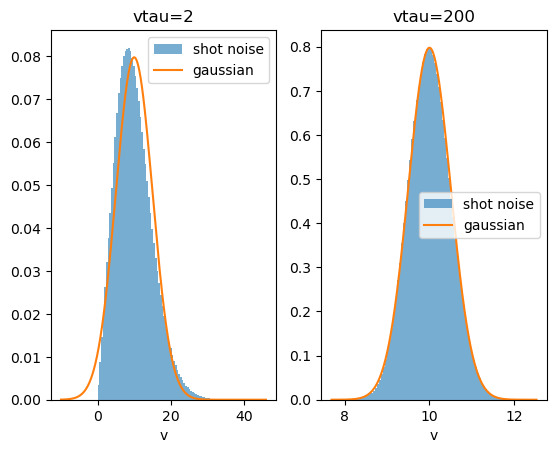

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import skew, norm

rng = np.random.default_rng(1)

tau = 0.020
ev = 10.0
dt = 0.001
T = 4000.0
burn = 1.0

v_tau = [2, 20, 200]


def sim_noise(nu, w):
    decay = np.exp(-dt / tau)
    block_steps = 1000
    block_time = block_steps * dt

    total_blocks = int(round((T + burn) / block_time))
    burn_blocks = int(round(burn / block_time))

    voltage = 0.0
    samples = []

    for block in range(total_blocks):
        n_events = rng.poisson(nu * block_time)
        event_times = rng.uniform(0, block_time, n_events)

        bins = (event_times / dt).astype(int)

        weights = w * np.exp(
            -((bins + 1) * dt - event_times) / tau
        )

        kicks = np.bincount(
            bins, weights=weights, minlength=block_steps
        )

        values, _ = lfilter(
            [1.0], [1.0, -decay],
            kicks,
            zi=[decay * voltage]
        )

        voltage = values[-1]

        if block >= burn_blocks:
            samples.append(values)

    return np.concatenate(samples)


results = {}

for i in v_tau:
    nu = i / tau
    w = ev / i

    voltage = sim_noise(nu, w)
    results[i] = voltage

    print(f"vtau = {i}")
    print(f"mean = {np.mean(voltage):.4g} ")
    print(f"variance = {np.var(voltage):.4g}")
    print(f"skewness = {skew(voltage):.4g}")
    print()


fig, axes = plt.subplots(1, 2)

for ax, q in zip(axes, [2, 200]):
    voltage = results[q]

    nu = q / tau
    w = ev / q
    variance = nu * w**2 * tau / 2
    sd = np.sqrt(variance)

    ax.hist(
        voltage, bins=100, density=True,
        alpha=0.6,
        label="shot noise"
    )

    x = np.linspace(
        min(voltage.min(), ev - 4*sd),
        max(voltage.max(), ev + 4*sd),
        1000
    )

    ax.plot(
        x, norm.pdf(x, loc=ev, scale=sd),
        label="gaussian"
    )

    ax.set(
        xlabel="v",
        title=rf"vtau={q}"
    )

    ax.legend()

plt.show()

--- Sigma^2 = 0.25 ---
Measured Firing Rate: 0.9898 (Expected: 1.0000)
Measured Fraction Below Reset: 24.12%
--- Sigma^2 = 1.0 ---
Measured Firing Rate: 0.9683 (Expected: 1.0000)
Measured Fraction Below Reset: 62.52%
--- Sigma^2 = 4.0 ---
Measured Firing Rate: 0.9629 (Expected: 1.0000)
Measured Fraction Below Reset: 87.86%


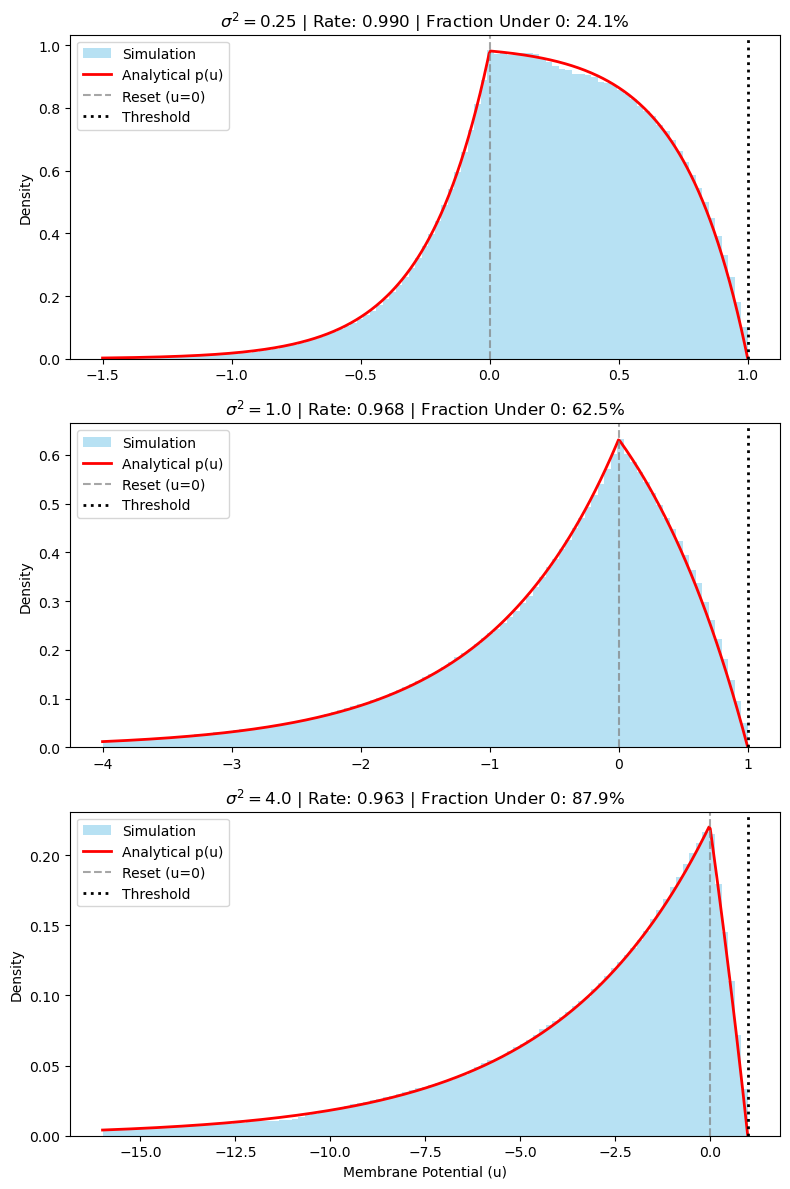

In [14]:
import numpy as np
import matplotlib.pyplot as plt

mu = 1.0
theta = 1.0
dt = 0.001
T_total = 1000.0          # Total simulation time
T_transient = 50.0        # Time to discard
steps_total = int(T_total / dt)
steps_transient = int(T_transient / dt)

sigma2s = [0.25, 1.0, 4.0]

# Analytical p(u) function
def analytical_p(u, sigma2):
    if u <= 0:
        return (mu/theta) / mu * (1 - np.exp(-mu*theta/sigma2)) * np.exp(mu*u/sigma2)
    elif 0 < u <= theta:
        return (mu/theta) / mu * (1 - np.exp(mu*(u-theta)/sigma2))
    else:
        return 0.0

# Vectorize to handle arrays for plotting
analytical_p_vec = np.vectorize(analytical_p)

# Plot setup
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=False)

for i, s2 in enumerate(sigma2s):
    sigma = np.sqrt(s2)
    
    # Pre-allocate array for voltage trajectory
    u_hist = np.zeros(steps_total - steps_transient)
    
    u = 0.0
    spike_count = 0
    below_reset_count = 0
    saved_idx = 0
    
    for step in range(steps_total):
        # Wiener increment
        dW = np.random.normal(0, np.sqrt(dt))
        
        # Drift + Diffusion update
        u += mu * dt + np.sqrt(2 * s2) * dW
        
        # Check threshold condition
        if u >= theta:
            u = 0.0
            if step >= steps_transient:
                spike_count += 1
                
        # Record statistics after the initial transient
        if step >= steps_transient:
            u_hist[saved_idx] = u
            if u < 0:
                below_reset_count += 1
            saved_idx += 1

    # Calculate metrics
    T_analysis = T_total - T_transient
    measured_firing_rate = spike_count / T_analysis
    measured_fraction_below = below_reset_count / len(u_hist)
    
    print(f"--- Sigma^2 = {s2} ---")
    print(f"Measured Firing Rate: {measured_firing_rate:.4f} (Expected: 1.0000)")
    print(f"Measured Fraction Below Reset: {measured_fraction_below*100:.2f}%")

    # Plotting Histogram vs. Analytical Curve
    ax = axes[idx]
    # Restrict histogram range to capture relevant distribution features
    u_min = -4 * s2 if s2 > 0.25 else -1.5
    bins = np.linspace(u_min, theta, 100)
    
    ax.hist(u_hist, bins=bins, density=True, alpha=0.6, color='skyblue', label='Simulation')
    
    u_axis = np.linspace(u_min, theta, 500)
    ax.plot(u_axis, analytical_p_vec(u_axis, s2), 'r-', lw=2, label='Analytical p(u)')
    
    ax.axvline(0, color='gray', linestyle='--', alpha=0.7, label='Reset (u=0)')
    ax.axvline(theta, color='black', linestyle=':', lw=2, label='Threshold')
    ax.set_title(f"$\\sigma^2 = {s2}$ | Rate: {measured_firing_rate:.3f} | Fraction Under 0: {measured_fraction_below*100:.1f}%")
    ax.set_ylabel("Density")
    if i == 2:
        ax.set_xlabel("Membrane Potential (u)")
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


sigma^2 = 0.25
Measured firing rate = 1.006
Measured fraction below reset = 0.2395

sigma^2 = 1.0
Measured firing rate = 0.983
Measured fraction below reset = 0.6308

sigma^2 = 4.0
Measured firing rate = 1.053
Measured fraction below reset = 0.8742



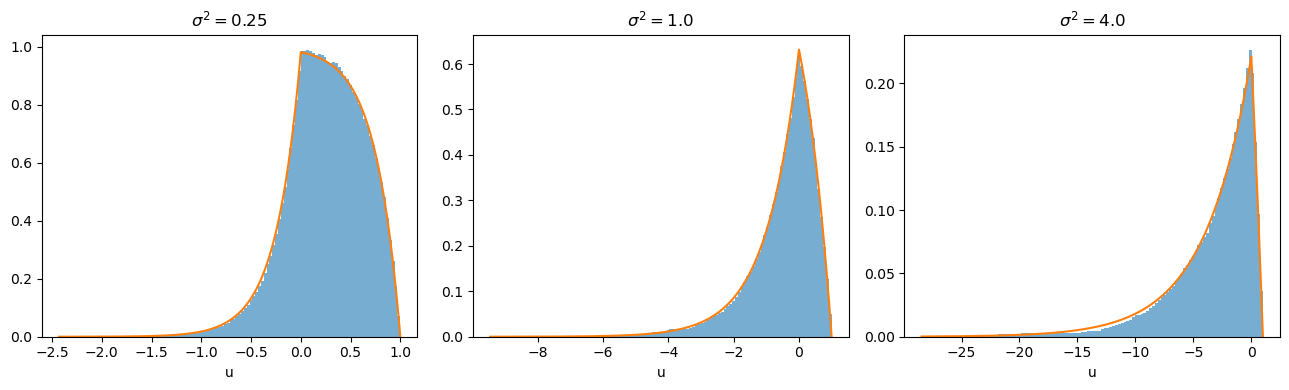

In [19]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

mu = 1.0
theta = 1.0

dt = 0.0001
T = 5000.0
InitialTransient = 50.0

sigma2_values = [0.25, 1.0, 4.0]


def stationary_density(u, sigma2):
    u = np.asarray(u)
    p = np.zeros_like(u, dtype=float)

    rate = mu / theta
    below = u < 0
    above = (u >= 0) & (u <= theta)

    factor = -np.expm1(-mu * theta / sigma2)

    p[below] = (
        (rate / mu)
        * factor
        * np.exp(mu * u[below] / sigma2)
    )

    p[above] = (
        (rate / mu)
        * (-np.expm1(mu * (u[above] - theta) / sigma2))
    )

    return p


def simulate(sigma2):
    n_it = int(round(InitialTransient / dt))
    n_record = int(round(T / dt))
    n_total = n_it + n_record

    noise_scale = np.sqrt(2 * sigma2 * dt)

    u = 0.0
    spikes = 0
    below_count = 0
    samples = []

    sample_stride = 20
    chunk_size = 100000

    for start in range(0, n_total, chunk_size):
        size = min(chunk_size, n_total - start)
        noises = rng.standard_normal(size)

        for j, z in enumerate(noises):
            i = start + j

            u += mu * dt + noise_scale * z

            if u >= theta:
                u = 0.0
                if i >= n_it:
                    spikes += 1

            if i >= n_it:
                if u < 0:
                    below_count += 1

                if (i - n_it) % sample_stride == 0:
                    samples.append(u)

    firing_rate = spikes / (n_record * dt)
    fraction_below = below_count / n_record

    return np.array(samples), firing_rate, fraction_below


fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, sigma2 in zip(axes, sigma2_values):
    samples, rate_sim, below_sim = simulate(sigma2)

    print(f"sigma^2 = {sigma2}")
    print(f"Measured firing rate = {rate_sim:.4g}")
    print(f"Measured fraction below reset = {below_sim:.4g}")
    print()

    ax.hist(
        samples,
        bins=120,
        density=True,
        alpha=0.6
    )

    u_grid = np.linspace(
        min(samples.min(), -1.0), theta, 2000
    )

    ax.plot(
        u_grid,
        stationary_density(u_grid, sigma2)
    )

    ax.set(
        xlabel="u",
        title=rf"$\sigma^2={sigma2}$"
    )

plt.tight_layout()
plt.show()